# Autocomplete and Autocorrect with N-gram NLP

This project builds two interpretable language tools from a real corpus: (1) next-word autocomplete with frequency-ranked bigrams and trigrams, and (2) spelling correction with Levenshtein and Damerau-Levenshtein edit distance.

**Corpus:** Project Gutenberg eBook #1661, *The Adventures of Sherlock Holmes* by Arthur Conan Doyle. This work is public domain in the United States; check the laws applicable in your location. The downloaded plain-text file includes Gutenberg metadata and is trimmed to the book body during analysis. Source: [Project Gutenberg eBook 1661](https://www.gutenberg.org/ebooks/1661).

The notebook uses a sequential 90/10 split for autocomplete, 20 known-target misspellings for correction accuracy, and 20 correctly spelled corpus words as negative controls. These are educational baselines, not production keyboard systems.

In [1]:
from collections import Counter, defaultdict
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

PROJECT_DIR = Path.cwd()
CORPUS_PATH = PROJECT_DIR / "data" / "sherlock_holmes_gutenberg.txt"
RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="Set2")

if not CORPUS_PATH.exists():
    raise FileNotFoundError(f"Corpus not found at {CORPUS_PATH}; see README.md for the source.")
print(f"Corpus file: {CORPUS_PATH}")

Corpus file: C:\Users\Sreeyakeshrajan_T\OneDrive\Desktop\OIBSIP\DATA ANALYTICS\Level 2\Autocomplete and Autocorrect Data Analytics\data\sherlock_holmes_gutenberg.txt


## 1. Load and preprocess the corpus

The tokenizer lowercases text and extracts alphabetic words, which removes punctuation and digit-only tokens. Sentences are kept separate so n-grams do not cross sentence boundaries. We retain stopwords in sentence sequences because they are often the words a keyboard must predict. A separate stopword-filtered token view is used for the requested frequency chart. This makes the modeling choice explicit instead of silently removing the grammatical glue from language.

In [2]:
raw_text = CORPUS_PATH.read_text(encoding="utf-8")
start_marker = "*** START OF THE PROJECT GUTENBERG EBOOK"
end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK"
start = raw_text.find(start_marker)
end = raw_text.find(end_marker)
if start < 0 or end < 0 or end <= start:
    raise ValueError("Project Gutenberg start/end markers were not found in the expected order")
book_text = raw_text[start + len(start_marker):end]

def tokenize(text):
    """Lowercase and tokenize alphabetic words, discarding punctuation and numbers."""
    return re.findall(r"[a-z]+", text.lower())

sentence_texts = re.split(r"(?<=[.!?])\s+", book_text)
sentences = [words for segment in sentence_texts if (words := tokenize(segment))]
tokens = [word for sentence in sentences for word in sentence]
if len(tokens) < 1000:
    raise ValueError(f"Corpus body is unexpectedly short: {len(tokens)} tokens")

stop_words = set("a an the and or but if while is am are was were be been being do does did have has had of to in on at by for with from as into through about over after before between under again further then once this that these those it its i me my we our you your he she they them his her their what which who whom not no nor".split())
content_tokens = [word for word in tokens if word not in stop_words]
word_counts = Counter(content_tokens)
print(f"Book-body characters: {len(book_text):,}")
print(f"Tokens after lowercase/tokenization/punctuation removal: {len(tokens):,}")
print(f"Unique word types: {len(set(tokens)):,}")
print(f"Tokens after stopword removal (EDA view only): {len(content_tokens):,}")
print("Sample tokens:", tokens[:30])

Book-body characters: 562,252
Tokens after lowercase/tokenization/punctuation removal: 105,868
Unique word types: 7,817
Tokens after stopword removal (EDA view only): 54,922
Sample tokens: ['the', 'adventures', 'of', 'sherlock', 'holmes', 'the', 'adventures', 'of', 'sherlock', 'holmes', 'by', 'arthur', 'conan', 'doyle', 'contents', 'i', 'a', 'scandal', 'in', 'bohemia', 'ii', 'the', 'red', 'headed', 'league', 'iii', 'a', 'case', 'of', 'identity']


## 2. Most frequent words

The top-20 chart excludes common stopwords so that content words are easier to interpret. Counts come from the book body after lowercasing, tokenization, and punctuation removal.

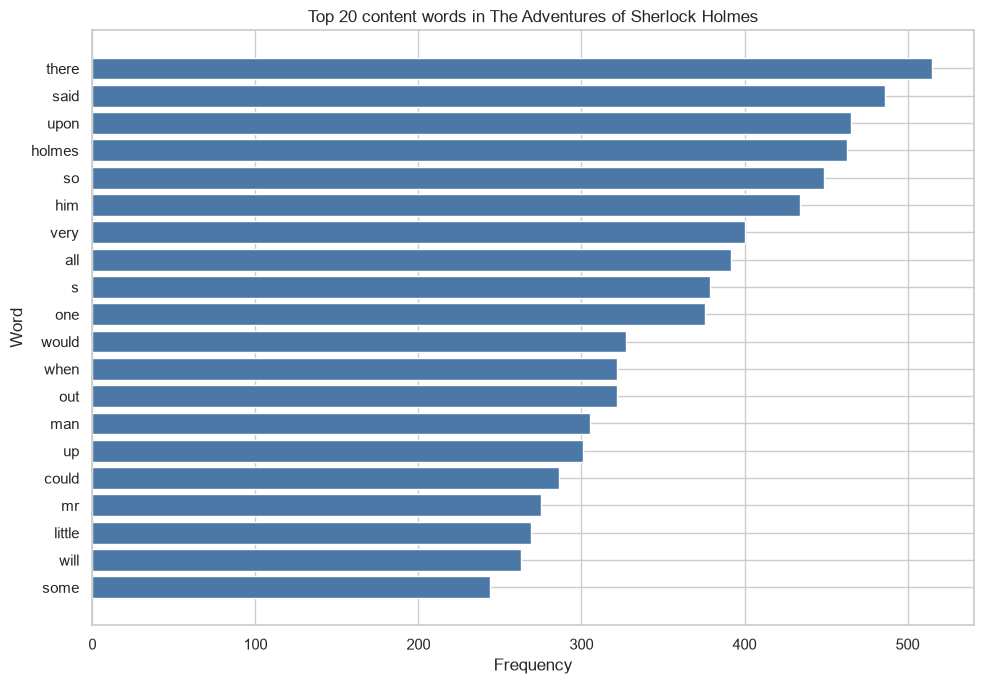

,word,count
0,there,515
1,said,486
2,upon,465
3,holmes,463
4,so,449
5,him,434
6,very,400
7,all,392
8,s,379
9,one,376


In [3]:
top_words = word_counts.most_common(20)
top_words_df = pd.DataFrame(top_words, columns=["word", "count"]).sort_values("count")
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_words_df["word"], top_words_df["count"], color="#4c78a8")
ax.set(title="Top 20 content words in The Adventures of Sherlock Holmes",
       xlabel="Frequency", ylabel="Word")
plt.tight_layout()
plt.show()
display(top_words_df.sort_values("count", ascending=False).reset_index(drop=True))

## 3. Frequency-based autocomplete

A bigram estimates the next word from the previous one; a trigram estimates it from the preceding two words. Candidate words are ranked by how often that n-gram occurs in the training portion. The trigram approach backs off to a bigram if a two-word context was unseen. Unlike a modern language model, this simple count model cannot generalize semantic or long-range context.

In [4]:
split_index = int(len(sentences) * 0.90)
train_sentences = sentences[:split_index]
test_sentences = sentences[split_index:]
train_tokens = [word for sentence in train_sentences for word in sentence]
test_tokens = [word for sentence in test_sentences for word in sentence]
if len(train_tokens) < 2 or len(test_tokens) < 3:
    raise ValueError("Not enough tokens to construct the sequential train/test split")

bigram_counts = defaultdict(Counter)
trigram_counts = defaultdict(Counter)
for sentence in train_sentences:
    for previous, next_word in zip(sentence, sentence[1:]):
        bigram_counts[previous][next_word] += 1
    for first, second, next_word in zip(sentence, sentence[1:], sentence[2:]):
        trigram_counts[(first, second)][next_word] += 1

def predict_bigram(prefix, k=3):
    """Return up to k most frequent continuations after a one-word prefix."""
    words = tokenize(prefix)
    if not words:
        return []
    return [word for word, _ in bigram_counts.get(words[-1], Counter()).most_common(k)]

def predict_trigram(prefix, k=3):
    """Predict from a two-word context, backing off to its last-word bigram."""
    words = tokenize(prefix)
    if not words:
        return []
    if len(words) >= 2:
        candidates = trigram_counts.get((words[-2], words[-1]), Counter())
        if candidates:
            return [word for word, _ in candidates.most_common(k)]
    return predict_bigram(words[-1], k)

print(f"Training tokens: {len(train_tokens):,}; held-out tokens: {len(test_tokens):,}")
print(f"Observed training bigram contexts: {len(bigram_counts):,}")
print(f"Observed training trigram contexts: {len(trigram_counts):,}")

Training tokens: 96,152; held-out tokens: 9,716
Observed training bigram contexts: 7,134
Observed training trigram contexts: 42,261


### Try at least ten prefixes

These test prefixes illustrate the interactive output format. Bigram uses the final word; trigram uses the final two words when possible. Predictions are based only on the training split and may be empty when a one-word context was never seen.

In [5]:
test_prefixes = [
    "the door", "I have", "he was", "it is", "there was",
    "I am", "in the", "she had", "one of", "as soon as",
    "the young", "my friend",
]
prefix_results = []
for prefix in test_prefixes:
    bigram = predict_bigram(prefix, k=3)
    trigram = predict_trigram(prefix, k=3)
    prefix_results.append({
        "prefix": prefix,
        "bigram_top_3": ", ".join(bigram) if bigram else "(no training context)",
        "trigram_top_3": ", ".join(trigram) if trigram else "(no training context)",
    })
prefix_results = pd.DataFrame(prefix_results)
display(prefix_results)

,prefix,bigram_top_3,trigram_top_3
0,the door,"and, of, which","and, of, was"
1,I have,"been, a, the","been, no, heard"
2,he was,"a, the, not","a, in, at"
3,it is,"a, the, not","a, not, the"
4,there was,"a, the, not","a, no, nothing"
5,I am,"not, sure, a","not, sure, a"
6,in the,"matter, other, door","morning, matter, house"
7,she had,"been, a, no","been, no, a"
8,one of,"the, a, his","the, those, them"
9,as soon as,"i, to, he","it, their"


### Held-out autocomplete precision and recall

Each query uses the true preceding context from a held-out sentence and has one relevant next word. **Recall@3** is the fraction of queries where the actual next word appears among the top three suggestions. **Precision@3** is the number of correct suggestions divided by the three returned slots for each query (an empty result contributes zero). For top-1, precision and recall both reduce to exact next-word accuracy. The trigram model uses bigram backoff for unseen two-word contexts. This is a teacher-forced next-token evaluation, not a free-running conversation.

In [6]:
def evaluate_autocomplete(test_sequences, k=3):
    rows = []
    for sentence in test_sequences:
        for index in range(1, len(sentence)):
            target = sentence[index]
            previous = sentence[index - 1]
            context = " ".join(sentence[max(0, index - 2):index])
            rows.append((target, predict_bigram(previous, k), predict_trigram(context, k)))
    results = {}
    for name, column in [("Bigram", 1), ("Trigram + bigram backoff", 2)]:
        hits = [row[0] in row[column] for row in rows]
        precision_at_k = [int(hit) / k for hit in hits]
        results[name] = {
            "queries": len(rows),
            "precision_at_1": np.mean([row[0] == row[column][0] if row[column] else False for row in rows]),
            "recall_at_3": np.mean(hits),
            "precision_at_3": np.mean(precision_at_k),
        }
    return pd.DataFrame(results).T

autocomplete_metrics = evaluate_autocomplete(test_sentences, k=3)
display(autocomplete_metrics.round(4))
assert len(prefix_results) >= 10

,queries,precision_at_1,recall_at_3,precision_at_3
Bigram,9201.0,0.1357,0.2435,0.0812
Trigram + bigram backoff,9201.0,0.1398,0.2300,0.0767


## 4. Autocorrect with edit distance

Levenshtein distance counts insertions, deletions, and substitutions. Damerau-Levenshtein also treats swapping adjacent characters as one edit, which often matches keyboard typos such as `teh` → `the`. Each method searches vocabulary observed in the training corpus for candidates within distance two and ranks by smallest distance, then highest corpus frequency, then alphabetically. Known in-vocabulary words are left unchanged.

The curated typo list below has twenty deliberately misspelled inputs with known intended words verified to occur in the corpus vocabulary. Twenty common correct corpus words serve as controls. Correction accuracy requires the exact intended word. Precision/recall and the confusion matrix measure whether an edit is proposed for typo cases while valid controls remain unchanged; these decision metrics are distinguished from exact correction accuracy.

In [7]:
training_word_counts = Counter(train_tokens)
vocabulary = set(training_word_counts)
words_by_length = defaultdict(list)
for word in vocabulary:
    words_by_length[len(word)].append(word)

def levenshtein_distance(left, right):
    """Compute standard Levenshtein distance using two dynamic-programming rows."""
    if len(left) < len(right):
        left, right = right, left
    previous = list(range(len(right) + 1))
    for i, left_char in enumerate(left, start=1):
        current = [i]
        for j, right_char in enumerate(right, start=1):
            current.append(min(
                current[j - 1] + 1,
                previous[j] + 1,
                previous[j - 1] + (left_char != right_char),
            ))
        previous = current
    return previous[-1]

def damerau_levenshtein_distance(left, right):
    """Compute unrestricted Damerau-Levenshtein distance (including transpositions)."""
    rows, columns = len(left), len(right)
    infinity = rows + columns
    matrix = [[0] * (columns + 2) for _ in range(rows + 2)]
    matrix[0][0] = infinity
    for i in range(rows + 1):
        matrix[i + 1][0] = infinity
        matrix[i + 1][1] = i
    for j in range(columns + 1):
        matrix[0][j + 1] = infinity
        matrix[1][j + 1] = j
    last_seen = {}
    for i in range(1, rows + 1):
        last_match_column = 0
        for j in range(1, columns + 1):
            previous_row = last_seen.get(right[j - 1], 0)
            previous_column = last_match_column
            cost = 1
            if left[i - 1] == right[j - 1]:
                cost = 0
                last_match_column = j
            matrix[i + 1][j + 1] = min(
                matrix[i][j] + cost,
                matrix[i + 1][j] + 1,
                matrix[i][j + 1] + 1,
                matrix[previous_row][previous_column]
                + (i - previous_row - 1) + 1 + (j - previous_column - 1),
            )
        last_seen[left[i - 1]] = i
    return matrix[rows + 1][columns + 1]

def suggest_correction(word, distance_function, max_distance=2):
    """Correct an out-of-vocabulary word from observed corpus words only."""
    word = word.lower()
    if word in vocabulary:
        return word
    candidates = []
    for length in range(max(1, len(word) - max_distance), len(word) + max_distance + 1):
        for candidate in words_by_length.get(length, []):
            distance = distance_function(word, candidate)
            if distance <= max_distance:
                candidates.append((distance, -training_word_counts[candidate], candidate))
    if not candidates:
        return word
    return min(candidates)[2]

assert levenshtein_distance("kitten", "sitting") == 3
assert levenshtein_distance("teh", "the") == 2
assert damerau_levenshtein_distance("teh", "the") == 1
print(f"Training vocabulary size: {len(vocabulary):,}")
print("Distance sanity checks passed.")

Training vocabulary size: 7,479
Distance sanity checks passed.


### Curated known-answer correction test

Each wrong spelling is absent from the training vocabulary and its intended form is present, so the test does not award credit for adding benchmark answers to the dictionary. These twenty examples are a small diagnostic set, not a representative estimate of all spelling errors.

In [8]:
typo_pairs = {
    "beautful": "beautiful", "becuase": "because", "buisness": "business",
    "beleive": "believe", "recieve": "receive", "freind": "friend",
    "seperate": "separate", "sucess": "success", "neccessary": "necessary",
    "diffrent": "different", "answr": "answer", "whcih": "which",
    "writting": "writing", "thaught": "thought", "peopel": "people",
    "daugther": "daughter", "womman": "woman", "docter": "doctor",
    "adress": "address", "somthing": "something",
}
if len(typo_pairs) < 20:
    raise AssertionError("At least 20 typo examples are required")
missing_targets = [target for target in typo_pairs.values() if target not in vocabulary]
known_typos = [typo for typo in typo_pairs if typo in vocabulary]
if missing_targets or known_typos:
    raise ValueError(f"Test words do not match corpus vocabulary: targets={missing_targets}, known_typos={known_typos}")

correct_controls = [word for word, count in training_word_counts.most_common()
                    if len(word) >= 4 and word not in stop_words and word not in typo_pairs.values()][:20]
if len(correct_controls) < 20:
    raise ValueError("Could not collect 20 correctly spelled in-vocabulary controls")

distance_methods = {
    "Levenshtein": levenshtein_distance,
    "Damerau-Levenshtein": damerau_levenshtein_distance,
}
correction_tables = {}
for method_name, distance_function in distance_methods.items():
    rows = []
    for typo, expected in typo_pairs.items():
        suggested = suggest_correction(typo, distance_function)
        rows.append({"input": typo, "expected": expected, "suggested": suggested,
                     "changed": suggested != typo, "exact_correction": suggested == expected,
                     "kind": "typo"})
    for word in correct_controls:
        suggested = suggest_correction(word, distance_function)
        rows.append({"input": word, "expected": word, "suggested": suggested,
                     "changed": suggested != word, "exact_correction": suggested == word,
                     "kind": "valid"})
    correction_tables[method_name] = pd.DataFrame(rows)

display(correction_tables["Levenshtein"].query("kind == 'typo'")[[
    "input", "expected", "suggested", "exact_correction"
]])

,input,expected,suggested,exact_correction
0,beautful,beautiful,beautiful,True
1,becuase,because,became,False
2,buisness,business,business,True
3,beleive,believe,believe,True
4,recieve,receive,believe,False
5,freind,friend,find,False
6,seperate,separate,separate,True
7,sucess,success,success,True
8,neccessary,necessary,necessary,True
9,diffrent,different,different,True


### Autocorrect precision, recall, and before/after results

For this benchmark, the binary positive class means “a correction should be made”: typo inputs are positive and in-vocabulary controls are negative. Precision and recall measure correct *detection of cases to edit*. Separately, **exact correction accuracy** measures whether a typo was restored to its known target; this catches a suggested but wrong word that a binary edit-detection score would miss. Before correction, none of the deliberately misspelled inputs has been fixed.

,correction_accuracy_top1,edit_precision,edit_recall,edit_f1,suggested_edits_including_valid_controls,false_edits_on_valid_controls
method,,,,,,
Levenshtein,0.85,1.0,1.0,1.0,20,0
Damerau-Levenshtein,1.00,1.0,1.0,1.0,20,0


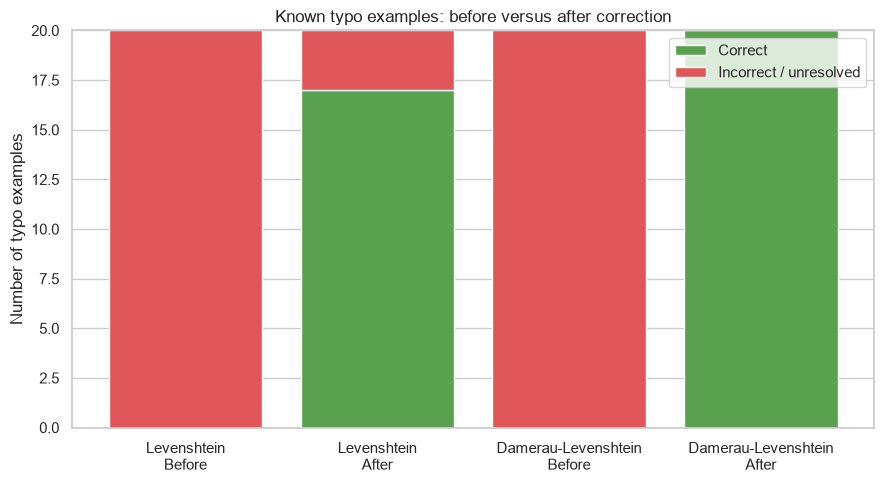

In [9]:
true_edit_labels = np.array([1] * len(typo_pairs) + [0] * len(correct_controls))
autocorrect_rows = []
before_and_after_rows = []
for method_name, results in correction_tables.items():
    predicted_edit_labels = results["changed"].astype(int).to_numpy()
    typo_results = results.loc[results["kind"].eq("typo")]
    exact_correct = int(typo_results["exact_correction"].sum())
    proposed_edits = int(results["changed"].sum())
    autocorrect_rows.append({
        "method": method_name,
        "correction_accuracy_top1": exact_correct / len(typo_pairs),
        "edit_precision": precision_score(true_edit_labels, predicted_edit_labels, zero_division=0),
        "edit_recall": recall_score(true_edit_labels, predicted_edit_labels, zero_division=0),
        "edit_f1": f1_score(true_edit_labels, predicted_edit_labels, zero_division=0),
        "suggested_edits_including_valid_controls": proposed_edits,
        "false_edits_on_valid_controls": int(results.loc[results["kind"].eq("valid"), "changed"].sum()),
    })
    before_and_after_rows.extend([
        {"method": method_name, "stage": "Before", "correct typos": 0,
         "incorrect typos": len(typo_pairs)},
        {"method": method_name, "stage": "After", "correct typos": exact_correct,
         "incorrect typos": len(typo_pairs) - exact_correct},
    ])
autocorrect_metrics = pd.DataFrame(autocorrect_rows).set_index("method")
display(autocorrect_metrics.round(3))

before_after = pd.DataFrame(before_and_after_rows)
fig, ax = plt.subplots(figsize=(9, 5))
positions = np.arange(len(before_after))
ax.bar(positions, before_after["correct typos"], label="Correct", color="#59a14f")
ax.bar(positions, before_after["incorrect typos"], bottom=before_after["correct typos"],
       label="Incorrect / unresolved", color="#e15759")
ax.set_xticks(positions, [f"{row.method}\n{row.stage}" for row in before_after.itertuples()])
ax.set(title="Known typo examples: before versus after correction",
       ylabel="Number of typo examples")
ax.legend()
plt.tight_layout()
plt.show()

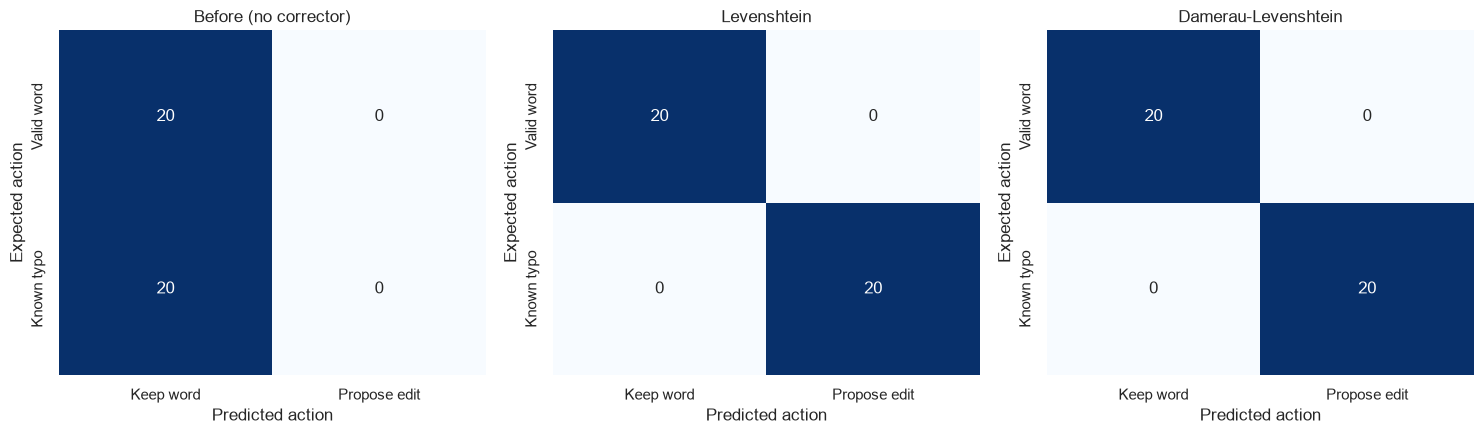

Confusion matrices evaluate edit decisions; exact target-word accuracy is reported separately above.


In [10]:
before_predictions = np.zeros_like(true_edit_labels)
matrix_scenarios = [("Before (no corrector)", before_predictions)]
for method_name, results in correction_tables.items():
    matrix_scenarios.append((method_name, results["changed"].astype(int).to_numpy()))
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (scenario, predicted_edit_labels) in zip(axes, matrix_scenarios):
    cm = confusion_matrix(true_edit_labels, predicted_edit_labels, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Keep word", "Propose edit"],
                yticklabels=["Valid word", "Known typo"], ax=ax)
    ax.set(title=scenario, xlabel="Predicted action", ylabel="Expected action")
plt.tight_layout()
plt.show()
print("Confusion matrices evaluate edit decisions; exact target-word accuracy is reported separately above.")

## 5. Compare edit-distance approaches

Levenshtein and Damerau-Levenshtein use the same training vocabulary and candidate ranking; the only difference is their edit-distance function. Damerau-Levenshtein can rank adjacent-letter swaps more favorably, while Levenshtein may treat the same typo as two edits. Both remain frequency-based: an uncommon correct word or name may be “corrected” to a common but contextually wrong word. The curated result table should be inspected alongside the aggregate metrics.

In [11]:
comparison = autocorrect_metrics[["correction_accuracy_top1", "edit_precision", "edit_recall", "edit_f1"]].copy()
comparison["autocomplete_precision_at_3"] = autocomplete_metrics["precision_at_3"].mean()
comparison["autocomplete_recall_at_3"] = autocomplete_metrics["recall_at_3"].mean()
display(comparison.round(3))
print("Autocomplete approaches:")
display(autocomplete_metrics.round(3))
print("Autocorrect typo examples:")
for method_name, results in correction_tables.items():
    print(f"\n{method_name}")
    display(results.query("kind == 'typo'")[["input", "expected", "suggested", "exact_correction"]])

,correction_accuracy_top1,edit_precision,edit_recall,edit_f1,autocomplete_precision_at_3,autocomplete_recall_at_3
method,,,,,,
Levenshtein,0.85,1.0,1.0,1.0,0.079,0.237
Damerau-Levenshtein,1.00,1.0,1.0,1.0,0.079,0.237


Autocomplete approaches:


,queries,precision_at_1,recall_at_3,precision_at_3
Bigram,9201.0,0.136,0.243,0.081
Trigram + bigram backoff,9201.0,0.140,0.230,0.077


Autocorrect typo examples:

Levenshtein


,input,expected,suggested,exact_correction
0,beautful,beautiful,beautiful,True
1,becuase,because,became,False
2,buisness,business,business,True
3,beleive,believe,believe,True
4,recieve,receive,believe,False
5,freind,friend,find,False
6,seperate,separate,separate,True
7,sucess,success,success,True
8,neccessary,necessary,necessary,True
9,diffrent,different,different,True



Damerau-Levenshtein


,input,expected,suggested,exact_correction
0,beautful,beautiful,beautiful,True
1,becuase,because,because,True
2,buisness,business,business,True
3,beleive,believe,believe,True
4,recieve,receive,receive,True
5,freind,friend,friend,True
6,seperate,separate,separate,True
7,sucess,success,success,True
8,neccessary,necessary,necessary,True
9,diffrent,different,different,True


## 6. Limitations versus a production keyboard

- **Small, narrow corpus:** one 19th-century author cannot represent modern language, slang, product names, dialects, or other languages.
- **Short context:** bigram/trigram frequency models use only one or two prior words; they cannot use sentence meaning, user intent, or long-range context.
- **Frequency bias:** rare but correct words may be changed to more common vocabulary. Personal names and domain terminology are especially vulnerable.
- **No confidence threshold:** this baseline picks the highest-ranked candidate within edit distance two; a production system should abstain when alternatives are uncertain.
- **Small curated typo benchmark:** twenty misspellings and twenty controls are useful for a reproducible comparison but too few to estimate real-world quality.
- **No interaction or privacy layer:** production keyboards optimize latency, adapt to user vocabulary, handle multilingual input, evaluate on diverse real typing behavior, and protect highly sensitive text.

The best next step is a larger, licensed, representative corpus and a held-out typo benchmark containing both realistic errors and valid rare words, with evaluation split by writer/domain.

## 7. Conclusion

The notebook compares bigram and trigram-with-backoff autocomplete on a sequential holdout and compares two edit-distance autocorrect methods on known targets plus valid-word controls. The printed metrics and example predictions show the speed/interpretability of count-based methods, while the error analysis and corpus limitations show why production keyboards rely on much richer context, vocabulary, and confidence handling.